# Event Display Quicklook

This notebook reuses the event display logic from `mlpf/macros/draw_events.py` to plot a single event from a parquet file (hits + tracks) in 3D using Plotly.

In [6]:
import awkward as ak
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
import time 
pio.renderers.default = "notebook_connected"

def _is_sequence_array(arr):
    return (
        arr.ndim == 2
        or (arr.ndim == 1 and len(arr) > 0 and isinstance(arr[0], (list, np.ndarray)))
    )

def plot_event_display(parquet_path, event_index=0, show=True, save_png=True, png_filename=None):
    output = ak.from_parquet(parquet_path)
    if event_index < 0 or event_index >= len(output["X_hit"]):
        raise IndexError(f"event_index {event_index} out of range")

    symbols = ["cross", "x", "circle", "square", "diamond"]

    X_hit = output["X_hit"][event_index]
    X_track = output["X_track"][event_index]

    hit_x = np.array(X_hit[:, 6])
    hit_y = np.array(X_hit[:, 7])
    hit_z = np.array(X_hit[:, 8])
    hit_e = np.array(X_hit[:, 5])
    hit_type = np.array(X_hit[:, -2]) + 1
    genlink_hits = np.array(output["ygen_hit"][event_index])

    track_x = np.array(X_track[:, 12])
    track_y = np.array(X_track[:, 13])
    track_z = np.array(X_track[:, 14])
    genlink_tracks = np.array(output["ygen_track"][event_index])

    if len(hit_x) == 0 and len(track_x) == 0:
        print("No hits or tracks in this event.")
        return None

    if len(genlink_hits) > 0 and len(genlink_tracks) > 0:
        genlink_all = np.concatenate((genlink_hits, genlink_tracks), axis=0)
    elif len(genlink_hits) > 0:
        genlink_all = genlink_hits
    else:
        genlink_all = genlink_tracks

    cmin = genlink_all.min()
    cmax = genlink_all.max()

    fig = go.Figure()

    if len(hit_x) > 0:
        marker_sizes = 10 * hit_e / hit_e
        for tval in np.unique(hit_type):
            mask = hit_type == tval
            fig.add_trace(
                go.Scatter3d(
                    x=hit_x[mask],
                    y=hit_y[mask],
                    z=hit_z[mask],
                    mode="markers",
                    name=f"hit_type {tval}",
                    marker=dict(
                        size=marker_sizes[mask],
                        color=genlink_hits[mask],
                        colorscale="Turbo",
                        cmin=cmin,
                        cmax=cmax,
                        opacity=0.8,
                        symbol=symbols[int(tval) % len(symbols)],
                        colorbar=dict(title="genlink0"),
                        showscale=bool(tval == np.unique(hit_type)[0]),
                    ),
                    text=[
                        f"type={tt}, e={ee:.2f}, gen={gg}"
                        for tt, ee, gg in zip(hit_type[mask], hit_e[mask] * 1e3, genlink_hits[mask])
                    ],
                    hoverinfo="text",
                )
            )

    if len(track_x) > 0:
        if _is_sequence_array(track_x):
            for idx in range(len(track_x)):
                x = np.array(track_x[idx])
                y = np.array(track_y[idx])
                z = np.array(track_z[idx])
                fig.add_trace(
                    go.Scatter3d(
                        x=x,
                        y=y,
                        z=z,
                        mode="lines",
                        name="track",
                        line=dict(color="white", width=3),
                        showlegend=bool(idx == 0),
                    )
                )
        else:
            fig.add_trace(
                go.Scatter3d(
                    x=track_x,
                    y=track_y,
                    z=track_z,
                    mode="markers",
                    name="tracks",
                    marker=dict(
                        size=6,
                        color=genlink_tracks,
                        colorscale="Turbo",
                        cmin=cmin,
                        cmax=cmax,
                        opacity=0.9,
                        symbol="diamond",
                        showscale=False,
                    ),
                )
            )

    fig.update_layout(
        scene=dict(
            xaxis_title="x",
            yaxis_title="y",
            zaxis_title="z",
            xaxis=dict(
                backgroundcolor="black",
                gridcolor="gray",
                showbackground=True,
                zerolinecolor="gray",
            ),
            yaxis=dict(
                backgroundcolor="black",
                gridcolor="gray",
                showbackground=True,
                zerolinecolor="gray",
            ),
            zaxis=dict(
                backgroundcolor="black",
                gridcolor="gray",
                showbackground=True,
                zerolinecolor="gray",
            ),
        ),
        paper_bgcolor="black",
        plot_bgcolor="black",
        margin=dict(l=0, r=0, b=0, t=0),
        legend=dict(title="Hit Type"),
        title=f"Event {event_index}",
    )

    if save_png:
        if png_filename is None:
            png_filename = f"event_{event_index + 1:04d}.png"
        fig.write_image(png_filename)

    if show:
        fig.show()

    return fig

In [7]:
CLD_PARQUET_DIR = "/eos/experiment/fcc/ee/simulation/key4hep_2024_10_03/91GeV/CLD_ARC/5k_training/05"
ARC_PARQUET_DIR = "/eos/experiment/fcc/ee/simulation/key4hep_2024_10_03/91GeV/CLD_ARC/5k_training/arc"

EVENT_INDEX = 60
FILE_INDEX = 21

Plot 3d Event...
2026-02-23 14:48:53


Plot 2D Eta-Phi...
2026-02-23 14:48:56


Compute ARC Residuals over Events...
2026-02-23 14:48:56
Compute CLD Residuals over Events...
2026-02-23 14:49:28
Plot Residuals Comparison...
ARC: N=25375, mean=0.01141, median=0.00681, q68=0.01290
CLD: N=25375, mean=0.01138, median=0.00681, q68=0.01291


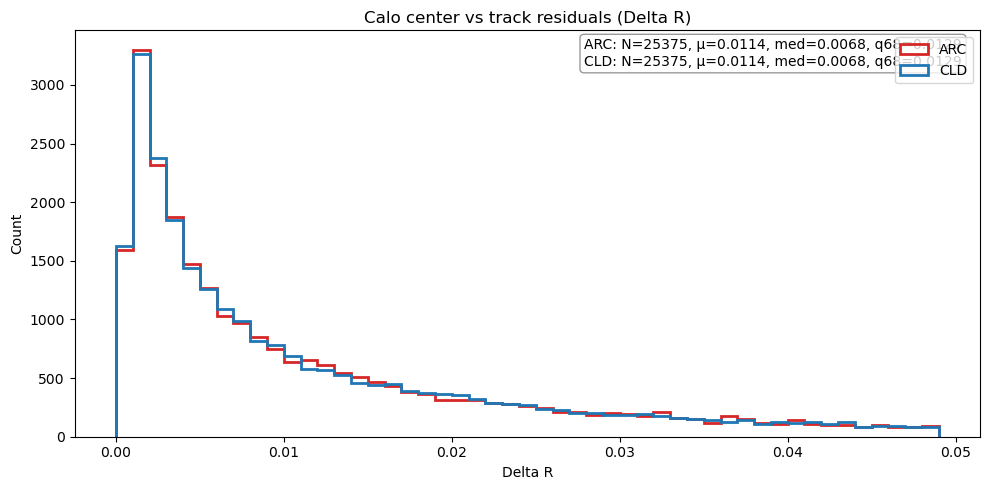

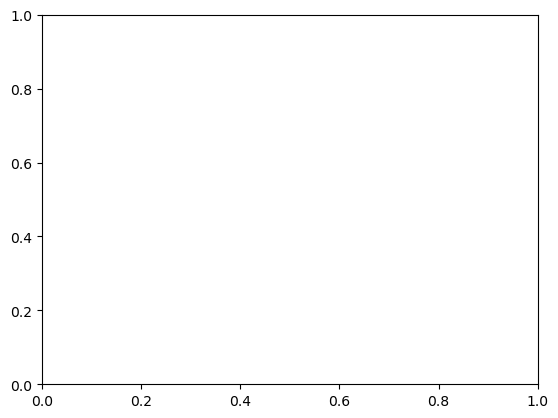

In [8]:
from arc_gen_extrapolation_check import (
    compute_linking_stats_over_events,
    compute_matching_matrix_over_events,
    compute_residuals_over_events,
    compute_residuals_with_energy_over_events,
    plot_delta_r_vs_cluster_energy_compare,
    plot_eta_phi_clusters_tracks,
    plot_event_3d,
    plot_linking_summary_compare,
    plot_matching_matrix_compare,
    plot_residuals_compare,
 )

ARC_EVENT_INDEX = EVENT_INDEX
print("Plot 3d Event...")
print(time.strftime("%Y-%m-%d %H:%M:%S"))
ARC_3D = plot_event_3d(
    ARC_PARQUET_DIR,
    event_index=ARC_EVENT_INDEX,
    file_index=FILE_INDEX,
    show=True,
    save_png=True,
    png_filename=f"event_arc_{ARC_EVENT_INDEX + 1:04d}_3d.png",
)
print("Plot 2D Eta-Phi...")
print(time.strftime("%Y-%m-%d %H:%M:%S"))
ARC_ETA_PHI = plot_eta_phi_clusters_tracks(
    ARC_PARQUET_DIR,
    event_index=ARC_EVENT_INDEX,
    file_index=FILE_INDEX,
    show=True,
    save_png=True,
    png_filename=f"event_arc_{ARC_EVENT_INDEX + 1:04d}_etaphi.png",
)
print("Compute ARC Residuals over Events...")
print(time.strftime("%Y-%m-%d %H:%M:%S"))
ARC_RESIDUALS = compute_residuals_over_events(ARC_PARQUET_DIR, max_events=10000)
print("Compute CLD Residuals over Events...")
print(time.strftime("%Y-%m-%d %H:%M:%S"))
CLD_RESIDUALS = compute_residuals_over_events(CLD_PARQUET_DIR, max_events=10000)
print("Plot Residuals Comparison...")
RESIDUALS_FIG = plot_residuals_compare(
    ARC_RESIDUALS,
    CLD_RESIDUALS,
    max_dr=0.05,
    bin_width=0.001,
    show=True,
    save_png=True,
    png_filename=f"residuals_arc_vs_cld_{ARC_EVENT_INDEX + 1:04d}.png",
)

Note on the statistics in this plot:  
- N: Number of successful associations between track and calo cluster 
- μ (mean): Mean value of the calculated residuals (DeltaR) between track and cluster center.
- med (median): Median of the residuals.
- q68: 68% quantile of the residuals.

Interpretation:  
A smaller N in the ARC setup means that fewer tracks could be successfully matched to a calo cluster compared to the CLD setup. This can indicate fewer reconstructed tracks, less track fragmentation, or a lower fake rate in the ARC setup.

In [9]:
print("Compute ARC Linking Stats over Events...")
print(time.strftime("%Y-%m-%d %H:%M:%S"))
LINK_STATS_ARC = compute_linking_stats_over_events(
    ARC_PARQUET_DIR,
    max_events=10000,
    include_unlinked=True,
 )
print("Compute CLD Linking Stats over Events...")
print(time.strftime("%Y-%m-%d %H:%M:%S"))
LINK_STATS_CLD = compute_linking_stats_over_events(
    CLD_PARQUET_DIR,
    max_events=10000,
    include_unlinked=True,
 )
print("Plot Linking Summary Comparison...")
print(time.strftime("%Y-%m-%d %H:%M:%S"))
LINK_SUMMARY_FIG = plot_linking_summary_compare(
    LINK_STATS_ARC,
    LINK_STATS_CLD,
    show=True,
    save_png=True,
    png_filename=f"linking_summary_arc_vs_cld_{ARC_EVENT_INDEX + 1:04d}.png",
)

Compute ARC Linking Stats over Events...
2026-02-23 14:50:04
Compute CLD Linking Stats over Events...
2026-02-23 14:50:31
Plot Linking Summary Comparison...
2026-02-23 14:50:57


Note on the statistics in this plot:  
- track_efficiency: Fraction of reconstructed tracks that could be matched to a calo cluster.
- cluster_purity: Fraction of calo clusters that could be matched to a reconstructed track.

Interpretation:  
In this comparison, ARC shows a slightly higher track efficiency, meaning a larger fraction of tracks are successfully linked to clusters. On the other hand, CLD has a slightly higher cluster purity, indicating that a larger fraction of clusters are matched to tracks. This suggests that ARC may have fewer fake or fragmented tracks, while CLD may have fewer fake or fragmented clusters.

In [10]:
print("Compute ARC Residuals over Events...")
print(time.strftime("%Y-%m-%d %H:%M:%S"))
ARC_RES_EN = compute_residuals_with_energy_over_events(
    ARC_PARQUET_DIR,
    max_events=10000,
    include_unlinked=True,
 )
print("Compute ARC Residuals over Events...")
print(time.strftime("%Y-%m-%d %H:%M:%S"))
CLD_RES_EN = compute_residuals_with_energy_over_events(
    CLD_PARQUET_DIR,
    max_events=10000,
    include_unlinked=True,
 )
print("Plot Delta R vs Cluster Energy Comparison...")
print(time.strftime("%Y-%m-%d %H:%M:%S"))
DELTA_R_EN_FIG = plot_delta_r_vs_cluster_energy_compare(
    ARC_RES_EN,
    CLD_RES_EN,
    max_dr=0.02,
    bins=60,
    show=True,
    save_png=True,
    png_filename=f"delta_r_vs_cluster_energy_arc_vs_cld_{ARC_EVENT_INDEX + 1:04d}.png",
)

Compute ARC Residuals over Events...
2026-02-23 14:50:57


Compute ARC Residuals over Events...
2026-02-23 14:51:30
Plot Delta R vs Cluster Energy Comparison...
2026-02-23 14:52:02


In [11]:
print("Compute ARC Matching Matrix over Events...")
print(time.strftime("%Y-%m-%d %H:%M:%S"))
ARC_MAT, ARC_LABELS = compute_matching_matrix_over_events(
    ARC_PARQUET_DIR,
    max_events=10000,
    include_unlinked=True,
 )
print("Compute ARC Matching Matrix over Events...")
print(time.strftime("%Y-%m-%d %H:%M:%S"))
CLD_MAT, CLD_LABELS = compute_matching_matrix_over_events(
    CLD_PARQUET_DIR,
    max_events=10000,
    include_unlinked=True,
 )
print("Plot comparisonm Matching Matrix over Events...")
print(time.strftime("%Y-%m-%d %H:%M:%S"))
MATCHING_MAT_FIG = plot_matching_matrix_compare(
    ARC_MAT,
    ARC_LABELS,
    CLD_MAT,
    CLD_LABELS,
    show=True,
    save_png=True,
    png_filename=f"matching_matrix_arc_vs_cld_{ARC_EVENT_INDEX + 1:04d}.png",
)

Compute ARC Matching Matrix over Events...
2026-02-23 14:52:03


Compute ARC Matching Matrix over Events...
2026-02-23 14:52:35
Plot comparisonm Matching Matrix over Events...
2026-02-23 14:53:07


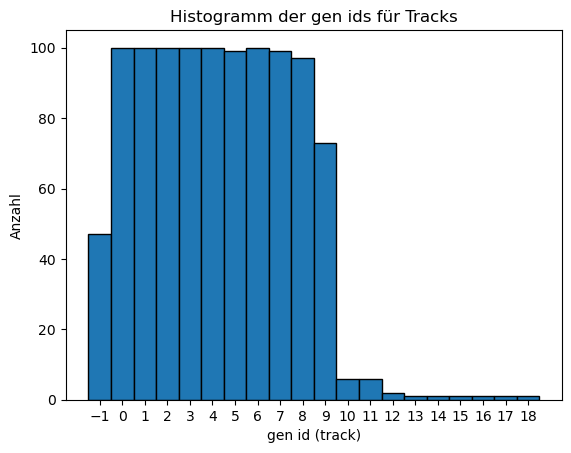

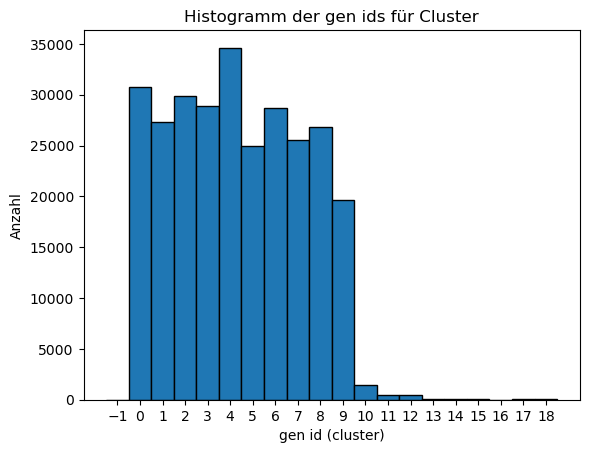

In [12]:
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

# Passe Pfad und file_index an!
parquet_path = "/eos/user/v/vriecher/mlpf_arc/CLD/train/eCH_10k/arc"
file_index = 0

def _list_parquet_files(path):
    import os
    if os.path.isdir(path):
        files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith(".parquet")]
        return sorted(files)
    return [path]

def _resolve_parquet_file(path, file_index=0):
    files = _list_parquet_files(path)
    if len(files) == 0:
        raise FileNotFoundError(f"No parquet files found in {path}")
    if file_index < 0 or file_index >= len(files):
        raise IndexError(f"file_index {file_index} out of range")
    return files[file_index]

parquet_file = _resolve_parquet_file(parquet_path, file_index=file_index)
output = ak.from_parquet(parquet_file)

# Tracks
all_gen_ids = np.concatenate([np.array(x) for x in output["ygen_track"]])
plt.hist(all_gen_ids, bins=np.arange(all_gen_ids.min(), all_gen_ids.max()+2)-0.5, edgecolor='black')
plt.xlabel("gen id (track)")
plt.ylabel("Anzahl")
plt.title("Histogramm der gen ids für Tracks")
plt.xticks(np.arange(all_gen_ids.min(), all_gen_ids.max()+1, 1))  # Integer-Ticks
plt.show()

# Cluster
all_gen_ids_cluster = np.concatenate([np.array(x) for x in output["ygen_hit"]])
plt.hist(all_gen_ids_cluster, bins=np.arange(all_gen_ids_cluster.min(), all_gen_ids_cluster.max()+2)-0.5, edgecolor='black')
plt.xlabel("gen id (cluster)")
plt.ylabel("Anzahl")
plt.title("Histogramm der gen ids für Cluster")
plt.xticks(np.arange(all_gen_ids_cluster.min(), all_gen_ids_cluster.max()+1, 1))  # Integer-Ticks
plt.show()

In [13]:
import awkward as ak
import numpy as np
import os

def count_clusters_with_high_genid(parquet_dir, max_files=None):
    files = [os.path.join(parquet_dir, f) for f in os.listdir(parquet_dir) if f.endswith(".parquet")]
    files = sorted(files)
    if max_files is not None:
        files = files[:max_files]
    total_events = 0
    count = 0
    for parquet_file in files:
        output = ak.from_parquet(parquet_file)
        n_events = len(output["ygen_hit"])
        total_events += n_events
        for i in range(n_events):
            cluster_ids = set(np.array(output["ygen_hit"][i]))
            track_ids = set(np.array(output["ygen_track"][i]))
            if len(track_ids) > 0:
                max_track_id = max(track_ids)
                high_cluster_ids = [cid for cid in cluster_ids if cid > max_track_id]
                if len(high_cluster_ids) > 0:
                    count += 1
    return count, total_events

# Beispielaufruf für ARC und CLD (max_files kann optional gesetzt werden)
arc_path = "/eos/user/v/vriecher/mlpf_arc/CLD/train/eCH_10k/arc"
cld_path = "/eos/user/v/vriecher/mlpf_arc/CLD/train/eCH_10k/05"
arc_count, arc_total = count_clusters_with_high_genid(arc_path)
cld_count, cld_total = count_clusters_with_high_genid(cld_path)
print(f"ARC: {arc_count} of {arc_total} events have clusters with gen id > max(track gen id)")
print(f"CLD: {cld_count} of {cld_total} events have clusters with gen id > max(track gen id)")

ARC: 280 of 10000 events have clusters with gen id > max(track gen id)
CLD: 249 of 10000 events have clusters with gen id > max(track gen id)


In [14]:
import awkward as ak
import numpy as np
import os

def count_fake_tracks(parquet_dir, max_files=None):
    files = [os.path.join(parquet_dir, f) for f in os.listdir(parquet_dir) if f.endswith(".parquet")]
    files = sorted(files)
    if max_files is not None:
        files = files[:max_files]
    total_events = 0
    fake_count = 0
    for parquet_file in files:
        output = ak.from_parquet(parquet_file)
        n_events = len(output["ygen_track"])
        total_events += n_events
        for i in range(n_events):
            track_ids = np.array(output["ygen_track"][i])
            # Fake tracks: gen id == -1
            fake_tracks = np.sum(track_ids == -1)
            fake_count += fake_tracks
    return fake_count, total_events

def count_fragmented_tracks(parquet_dir, max_files=None):
    files = [os.path.join(parquet_dir, f) for f in os.listdir(parquet_dir) if f.endswith(".parquet")]
    files = sorted(files)
    if max_files is not None:
        files = files[:max_files]
    total_events = 0
    frag_count = 0
    for parquet_file in files:
        output = ak.from_parquet(parquet_file)
        n_events = len(output["ygen_track"])
        total_events += n_events
        for i in range(n_events):
            track_ids = np.array(output["ygen_track"][i])
            # Fragmentation: count gen ids that appear more than once (excluding -1)
            unique, counts = np.unique(track_ids[track_ids != -1], return_counts=True)
            fragments = np.sum(counts > 1)
            frag_count += fragments
    return frag_count, total_events

# Beispielaufruf für ARC und CLD
arc_path = "/eos/user/v/vriecher/mlpf_arc/CLD/train/eCH_10k/arc"
cld_path = "/eos/user/v/vriecher/mlpf_arc/CLD/train/eCH_10k/05"

arc_fake, arc_total = count_fake_tracks(arc_path)
cld_fake, cld_total = count_fake_tracks(cld_path)
print(f"ARC: {arc_fake} fake tracks in {arc_total} events")
print(f"CLD: {cld_fake} fake tracks in {cld_total} events")

arc_frag, arc_total = count_fragmented_tracks(arc_path)
cld_frag, cld_total = count_fragmented_tracks(cld_path)
print(f"ARC: {arc_frag} fragmented gen ids in {arc_total} events")
print(f"CLD: {cld_frag} fragmented gen ids in {cld_total} events")

ARC: 5257 fake tracks in 10000 events
CLD: 5436 fake tracks in 10000 events
ARC: 0 fragmented gen ids in 10000 events
CLD: 0 fragmented gen ids in 10000 events


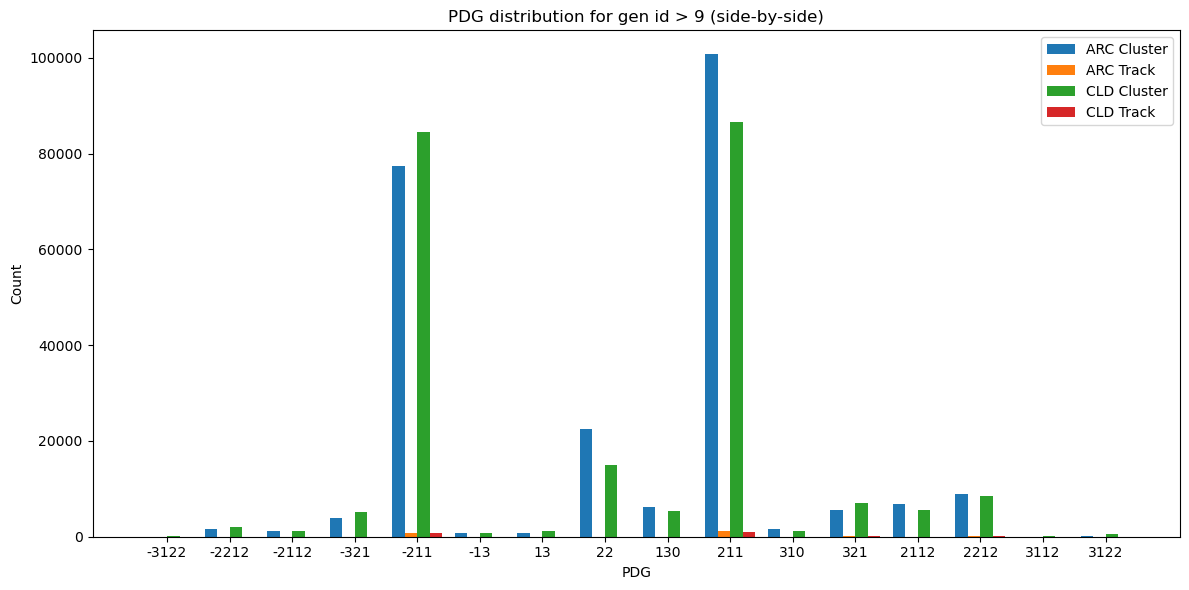

In [15]:
import awkward as ak
import numpy as np
import os
import matplotlib.pyplot as plt

def get_pdg_for_high_genid(parquet_dir, max_files=None, genid_threshold=9):
    files = [os.path.join(parquet_dir, f) for f in os.listdir(parquet_dir) if f.endswith(".parquet")]
    files = sorted(files)
    pdgs_hit = []
    pdgs_track = []
    if max_files is not None:
        files = files[:max_files]
    for parquet_file in files:
        output = ak.from_parquet(parquet_file)
        n_events = len(output["ygen_hit"])
        for i in range(n_events):
            gen_ids_hit = np.array(output["ygen_hit"][i])
            gen_ids_track = np.array(output["ygen_track"][i])
            if "X_gen" in output.fields:
                X_gen = output["X_gen"][i]
                gen_pdg = np.array(X_gen[:, 0]) if len(X_gen) > 0 else None
            else:
                gen_pdg = None
            for genid in gen_ids_hit:
                if genid > genid_threshold and gen_pdg is not None and genid < len(gen_pdg):
                    pdgs_hit.append(int(gen_pdg[int(genid)]))
            for genid in gen_ids_track:
                if genid > genid_threshold and gen_pdg is not None and genid < len(gen_pdg):
                    pdgs_track.append(int(gen_pdg[int(genid)]))
    return pdgs_hit, pdgs_track

# Beispielaufruf für ARC und CLD
arc_path = "/eos/user/v/vriecher/mlpf_arc/CLD/train/eCH_10k/arc"
cld_path = "/eos/user/v/vriecher/mlpf_arc/CLD/train/eCH_10k/05"
arc_pdgs_hit, arc_pdgs_track = get_pdg_for_high_genid(arc_path)
cld_pdgs_hit, cld_pdgs_track = get_pdg_for_high_genid(cld_path)

# Alle vorkommenden PDGs
all_pdgs = sorted(set(arc_pdgs_hit + arc_pdgs_track + cld_pdgs_hit + cld_pdgs_track))

# Zähle pro PDG
def count_pdgs(pdgs, pdg_list):
    return [pdgs.count(pdg) for pdg in pdg_list]

arc_hit_counts = count_pdgs(arc_pdgs_hit, all_pdgs)
arc_track_counts = count_pdgs(arc_pdgs_track, all_pdgs)
cld_hit_counts = count_pdgs(cld_pdgs_hit, all_pdgs)
cld_track_counts = count_pdgs(cld_pdgs_track, all_pdgs)

bar_width = 0.2
x = np.arange(len(all_pdgs))

plt.figure(figsize=(12, 6))
plt.bar(x - 1.5*bar_width, arc_hit_counts, width=bar_width, label="ARC Cluster")
plt.bar(x - 0.5*bar_width, arc_track_counts, width=bar_width, label="ARC Track")
plt.bar(x + 0.5*bar_width, cld_hit_counts, width=bar_width, label="CLD Cluster")
plt.bar(x + 1.5*bar_width, cld_track_counts, width=bar_width, label="CLD Track")
plt.xlabel("PDG")
plt.ylabel("Count")
plt.title("PDG distribution for gen id > 9 (side-by-side)")
plt.xticks(x, all_pdgs)
plt.legend()
plt.tight_layout()
plt.show()

Could the fact that in 280 out of 10,000 ARC events and 249 out of 10,000 CLD events there are clusters with a gen id greater than any track gen id indicate that secondary particles or additional processes (e.g. scattering in the ARC material) are producing clusters without corresponding tracks?